# 3. Classificação e Avaliação
Este notebook carrega as features extraídas, realiza a divisão estratificada dos dados, aplica padronização sem vazamento de informação e treina classificadores clássicos.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

X = pd.read_csv('outputs/X.csv')
y = pd.read_csv('outputs/y.csv').squeeze()

### ==========================================
## 1.5 ANÁLISE VISUAL DAS FEATURES (BOXPLOTS)
### ==========================================

/tmp/ipykernel_38145/4058411627.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df_analise, ax=axes[i], palette='Set2')
/tmp/ipykernel_38145/4058411627.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df_analise, ax=axes[i], palette='Set2')
/tmp/ipykernel_38145/4058411627.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df_analise, ax=axes[i], palette='Set2')
/tmp/ipykernel_38145/4058411627.py:15: FutureWarning: 

Passing `palette` without assigning

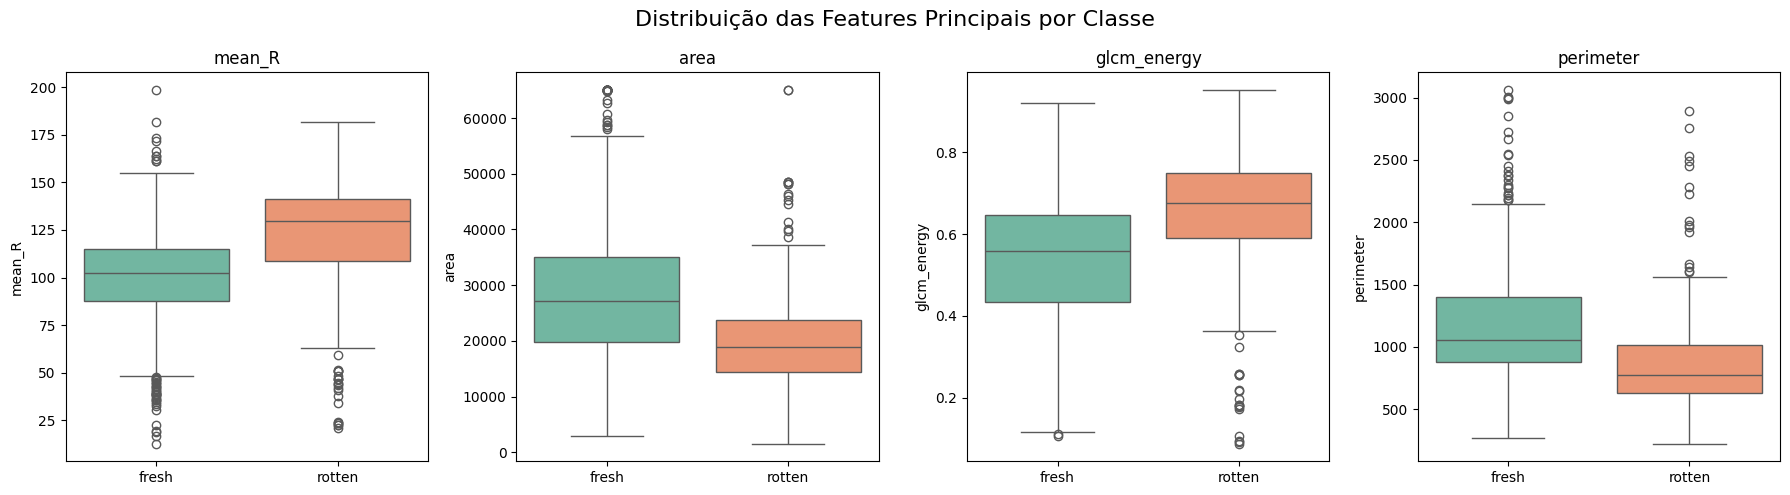

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Juntando X e y temporariamente apenas para facilitar o plot
df_analise = X.copy()
df_analise['label'] = y

# Selecionando as features que sabemos que são mais impactantes (via SHAP)
features_chave = ['mean_R', 'area', 'glcm_energy', 'perimeter']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Distribuição das Features Principais por Classe', fontsize=16)

for i, feature in enumerate(features_chave):
    sns.boxplot(x='label', y=feature, data=df_analise, ax=axes[i], palette='Set2')
    axes[i].set_title(feature)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

## Divisão Estratificada e Pré-Processamento
Divisão dos dados em treino (60%), validação (20%) e teste (20%). O StandardScaler é ajustado exclusivamente nos dados de treino.

In [19]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## Treinamento e Avaliação
Treinamento do Random Forest e Support Vector Machine (SVM), seguido da avaliação quantitativa e visualização das matrizes de confusão nos dados de teste reservados.

              precision    recall  f1-score   support

       fresh       0.89      0.83      0.86       120
      rotten       0.84      0.90      0.87       120

    accuracy                           0.87       240
   macro avg       0.87      0.87      0.87       240
weighted avg       0.87      0.87      0.87       240



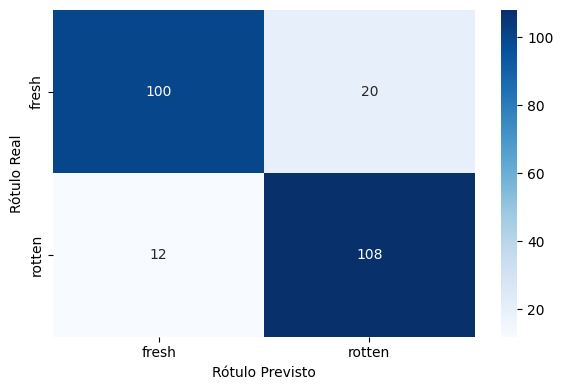

              precision    recall  f1-score   support

       fresh       0.84      0.84      0.84       120
      rotten       0.84      0.84      0.84       120

    accuracy                           0.84       240
   macro avg       0.84      0.84      0.84       240
weighted avg       0.84      0.84      0.84       240



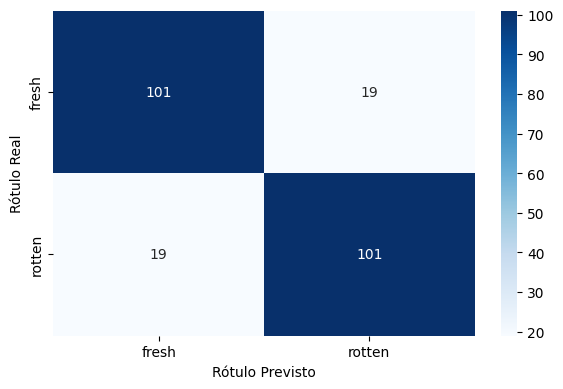

In [20]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

def evaluate_model(model, X_test_scaled, y_test):
    y_pred = model.predict(X_test_scaled)
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
    plt.ylabel('Rótulo Real')
    plt.xlabel('Rótulo Previsto')
    plt.tight_layout()
    plt.show()

evaluate_model(rf_model, X_test_scaled, y_test)
evaluate_model(svm_model, X_test_scaled, y_test)